# 2. Machine Learning for Regression

In [525]:
import numpy as np
import pandas as pd

## 2.2 Data preparation

In [526]:
df = pd.read_csv("data.csv")
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [527]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [528]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [529]:
strings = list(df.dtypes[df.dtypes == "str"].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [530]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(" ", "_")
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


## 2.3 Exploratory data analysis

In [531]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [532]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

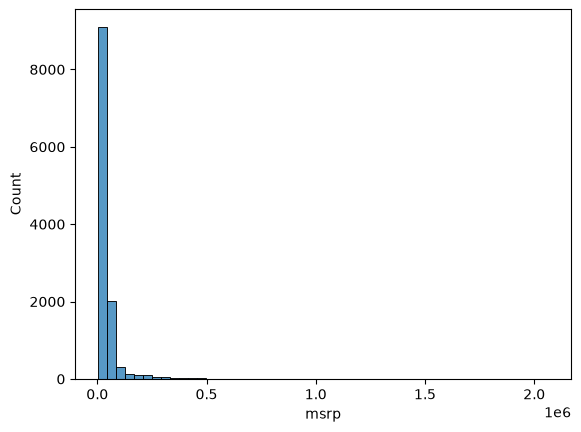

In [533]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

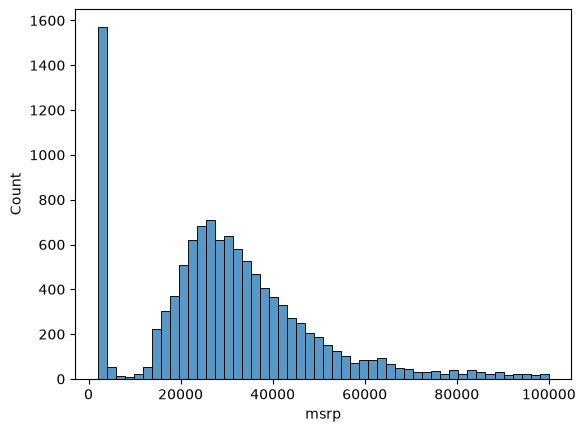

In [534]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [535]:
# Log will compress large values
np.log([1, 10, 100, 100000])

array([ 0.        ,  2.30258509,  4.60517019, 11.51292546])

In [536]:
# Though log of 0 doesn't exist, so we have to add one to everything
np.log([0, 10, 100, 100000])

/tmp/ipykernel_8440/3614555296.py:2: RuntimeWarning: divide by zero encountered in log
  np.log([0, 10, 100, 100000])


array([       -inf,  2.30258509,  4.60517019, 11.51292546])

In [537]:
np.log([0 + 1, 10 + 1, 100 + 1, 100000 + 1])

array([ 0.        ,  2.39789527,  4.61512052, 11.51293546])

In [538]:
# Which is equivalent to
np.log1p([0, 10, 100, 100000])

array([ 0.        ,  2.39789527,  4.61512052, 11.51293546])

<Axes: xlabel='msrp', ylabel='Count'>

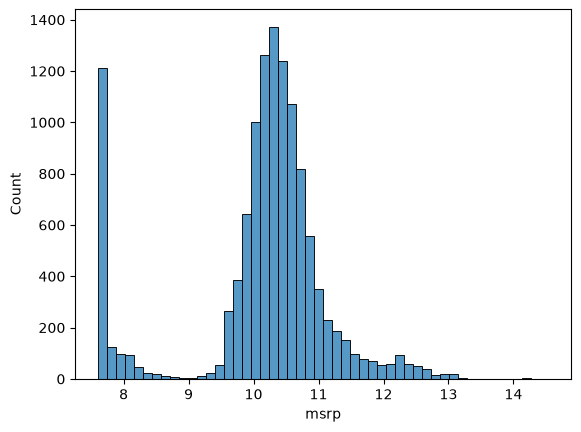

In [539]:
price_logs = np.log1p(df.msrp)
sns.histplot(price_logs, bins=50)
# Now is more like a bell curve - normal distribution, ideal for models
# Long tail distribution usually confuses model

In [540]:
# Missing values, need to keep in mind when train our model
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## 2.4 Setting up the validation framework

In [541]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

n, n_val, n_test, n_train

(11914, 2382, 2382, 7150)

In [542]:
df.iloc[11910:]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920
11913,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61,28995


In [543]:
# Shuffle data first
idx = np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)
idx


array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [544]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train : n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val :]]

In [545]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [546]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [547]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [548]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [549]:
# Delete price so that we won't accidentally use the log value
del df_train["msrp"]
del df_val["msrp"]
del df_test["msrp"]

## 2.5 Linear Regression

In [550]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [551]:
# engine_hp, city_mpg, popularity
xi = [453, 11, 86]

In [552]:
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [553]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [554]:
linear_regression(xi)

12.312

In [555]:
# short hand of np.exp(12.312) - 1
np.expm1(12.312) - 1

np.float64(222346.2221101062)

## 2.6 Linear regression vector form

In [556]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [557]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [558]:
w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.002]

In [559]:
def linear_regression(xi):
    return dot(xi, w_new)


linear_regression(xi)

3251.56

In [560]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = np.array([x1, x2, x10])
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [561]:
def linear_regression(X):
    return X.dot(w_new)

In [562]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

## 2.7 Training a linear regression model

In [563]:
X = np.array(
    [
        [148, 24, 1385],
        [132, 25, 2031],
        [453, 11, 86],
        [158, 24, 185],
        [172, 25, 201],
        [413, 11, 86],
        [38, 54, 185],
        [142, 25, 431],
        [453, 31, 86],
    ]
)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [564]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [565]:
X = np.column_stack([ones, X])
X

array([[1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03],
       [1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03],
       [1.000e+00, 4.530e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 1.580e+02, 2.400e+01, 1.850e+02],
       [1.000e+00, 1.720e+02, 2.500e+01, 2.010e+02],
       [1.000e+00, 4.130e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 3.800e+01, 5.400e+01, 1.850e+02],
       [1.000e+00, 1.420e+02, 2.500e+01, 4.310e+02],
       [1.000e+00, 4.530e+02, 3.100e+01, 8.600e+01]])

In [566]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [567]:
# w = (X^T X)^-1 X^T y
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)
w0 = w_full[0]
w = w_full[1:]

w0, w


(np.float64(25844.754055766833),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [568]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


In [569]:
X_original = X[:, 1:]
X_original

array([[ 148.,   24., 1385.],
       [ 132.,   25., 2031.],
       [ 453.,   11.,   86.],
       [ 158.,   24.,  185.],
       [ 172.,   25.,  201.],
       [ 413.,   11.,   86.],
       [  38.,   54.,  185.],
       [ 142.,   25.,  431.],
       [ 453.,   31.,   86.]])

In [570]:
train_linear_regression(X_original, y)

(np.float64(25844.754055766833),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

## 2.8 Car price baseline model

In [571]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [572]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

df_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


In [573]:
df_train[base].isna().sum()

# 0 is not the best way to deal with missinng variable, but sometimes okay.
# Can fill with mean value instead

X_train = df_train[base].fillna(0).values

In [574]:
w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(7.927257388070037),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [575]:
y_pred = w0 + X_train.dot(w)
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

<Axes: ylabel='Count'>

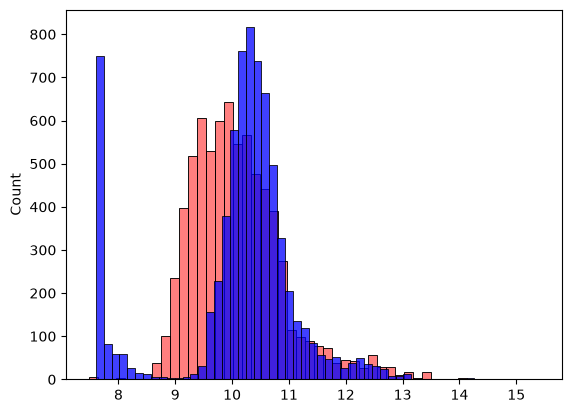

In [576]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50) # prediction
sns.histplot(y_train, color='blue', bins=50) # target

## 2.9 RMSE (Root Meean Squared Error)

In [577]:
def rmse(y, y_pred):
  se = (y - y_pred) ** 2
  mse = se.mean()
  return np.sqrt(mse)

In [578]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

## 2.10 Validating the model

In [579]:
def prepare_X(df):
  df_num = df[base]
  df_num = df_num.fillna(0)
  X = df_num.values
  return X

In [580]:
X_val = prepare_X(df_val)
y_pred_val = w0 + X_val.dot(w)
rmse(y_val, y_pred_val)

np.float64(0.7616530991301627)

## 2.11 Simple feature engineering

In [581]:
df_train.year.max()

np.int64(2017)

In [582]:
2017 - df_train.year

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [583]:
def prepare_X(df):
  df = df.copy() # prevenet mutatinng original df

  df['age'] = 2017 - df.year
  features = base + ['age']

  df_num = df[features]
  df_num = df_num.fillna(0)
  X = df_num.values
  return X

In [584]:
X_train = prepare_X(df_train)

In [585]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [586]:
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred_val = w0 + X_val.dot(w)

rmse(y_val, y_pred_val)

np.float64(0.5172055461058327)

<Axes: ylabel='Count'>

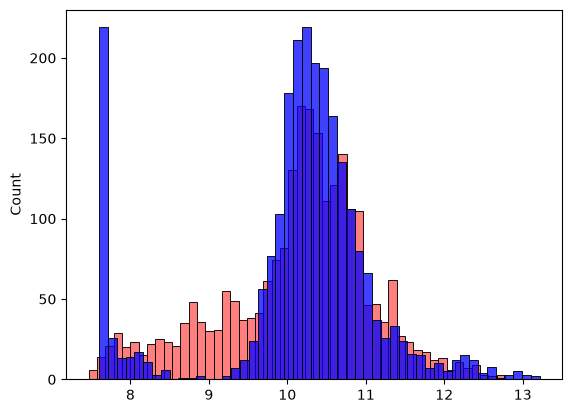

In [587]:
sns.histplot(y_pred_val, color='red', alpha=0.5, bins=50) # prediction
sns.histplot(y_val, color='blue', bins=50) # target

## 2.12 Categorical variables

In [588]:
df_train.number_of_doors.unique() # actually not numerical, categorical

array([ 2.,  4.,  3., nan])

In [589]:
for v in [2, 3, 4]:
  df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')

df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1,0,0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0,0,1
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0,0,1
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0,1,0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0,0,1


In [590]:
def prepare_X(df):
  df = df.copy() # prevenet mutatinng original df
  features = base.copy()

  df['age'] = 2017 - df.year
  features.append('age')

  for v in [2, 3, 4]:
    df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
    features.append('num_doors_%s' % v)


  df_num = df[features]
  df_num = df_num.fillna(0)
  X = df_num.values
  
  return X

In [591]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred_val = w0 + X_val.dot(w)

rmse(y_val, y_pred_val)

np.float64(0.5157995641501902)

In [592]:
df.make.value_counts().head()

make
chevrolet     1123
ford           881
volkswagen     809
toyota         746
dodge          626
Name: count, dtype: int64

In [593]:
makes = list(df.make.value_counts().head().index)
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [594]:
def prepare_X(df):
  df = df.copy()
  features = base.copy()

  df['age'] = 2017 - df.year
  features.append('age')

  for v in [2, 3, 4]:
    df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
    features.append('num_doors_%s' % v)

  for v in makes:
    df['make_%s' % v] = (df.make == v).astype('int')
    features.append('make_%s' % v)

  df_num = df[features]
  df_num = df_num.fillna(0)
  X = df_num.values
  
  return X

In [595]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred_val = w0 + X_val.dot(w)

rmse(y_val, y_pred_val)

np.float64(0.5076038849556633)

In [596]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

In [597]:
def prepare_X(df):
  df = df.copy()
  
  df['age'] = 2017 - df['year']
  features = base + ['age']

  for v in [2, 3, 4]:
      df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
      features.append('num_doors_%d' % v)

  for name, values in categorical.items():
      for value in values:
          df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
          features.append('%s_%s' % (name, value))

  df_num = df[features]
  df_num = df_num.fillna(0)
  X = df_num.values

  return X

In [598]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred_val = w0 + X_val.dot(w)

rmse(y_val, y_pred_val)

np.float64(113.55512071962342)

In [599]:
w0, w # the weightw are really high

(np.float64(-292975507188272.25),
 array([-1.94204667e-02, -8.44049639e+00,  4.18197946e-01, -7.24923387e-01,
        -1.43876150e-03, -7.43833334e-01,  8.71810032e+02,  8.46669570e+02,
         8.58349986e+02, -4.42390313e+00,  3.41491294e+00, -3.16297901e+00,
         8.58984632e+00, -1.15071526e+01, -1.96686350e+00, -1.07272250e+01,
        -4.82722874e+00, -2.93588658e+01, -6.00895660e+01, -9.18904890e+01,
        -8.66432254e+01, -9.59117190e+01, -8.73772648e+01, -9.92397920e+01,
         2.92975507e+14,  2.92975507e+14,  2.92975507e+14,  2.92975507e+14,
         2.47790122e+00,  1.90357987e+00, -4.57116994e+00, -4.32985422e-01,
        -2.87067662e+00, -2.92281644e+01, -3.80682704e+01, -3.58223622e+01,
        -1.44115660e-01, -2.62579827e-02,  1.75913981e-01,  3.65037816e-01,
        -2.90235596e-01]))

## 2.13 Regilarization

In [600]:
# Some time (XTX)-1 doesn't exist if there are duplicated features, fix by
# adding small number so its not duplicated
XTX = [
  [1, 2, 2],
  [2, 1, 1.0000001],
  [2, 1.0000001, 1],
]

XTX = np.array(XTX)

In [601]:
np.linalg.inv(XTX)

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

In [602]:
# To solve big weight problem can add a small number at the diagonal of the matrix
# this is called rigularisation (control the number of the weights)
XTX = XTX + 0.01 * np.eye(3)
np.linalg.inv(XTX)

array([[ -0.33668908,   0.33501399,   0.33501399],
       [  0.33501399,  49.91590897, -50.08509104],
       [  0.33501399, -50.08509104,  49.91590897]])

In [603]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [604]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.4608208286405126)

## 2.14 Tuning the model

In [605]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, w0, score)

0.0 -292975507188272.25 113.55512071962342
1e-05 7.877078971380707 0.4608153161997021
0.0001 7.135017378207604 0.46081536448154503
0.001 7.131037736232789 0.4608158583830182
0.1 7.000232407249966 0.4608736549126053
1 6.250747847380808 0.46158128382721536
10 4.729512585714188 0.47260987726669534


In [606]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.4608158583830182)

## 2.15 Using the model

In [607]:
# Train the model using the both train and val dataset
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
df_full_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1.0,0.0,0.0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0.0,0.0,1.0
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0.0,0.0,1.0
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0.0,1.0,0.0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0.0,0.0,1.0


In [608]:
X_full_train = prepare_X(df_full_train)
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [609]:
y_full_train = np.concatenate([y_train, y_val])
y_full_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 11.21756062,
        9.77542688, 10.1924563 ], shape=(9532,))

In [610]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [611]:
w0, w

(np.float64(7.175122906174352),
 array([ 1.80193323e-03,  1.26575150e-01, -6.78607869e-03,  7.75903944e-03,
        -5.33226045e-05, -9.73063833e-02, -1.27241551e+00, -1.30599119e+00,
        -9.95968845e-01, -6.27479237e-02,  1.82139249e-01,  2.83073943e-02,
         1.29063899e-02, -1.32624473e-01, -2.69110366e-01, -6.50985209e-01,
        -3.21721815e-01, -3.55424918e-01, -3.51216100e-01, -6.61059030e-01,
        -1.19526928e-01, -5.15904828e-01, -6.99730869e-01, -3.25276693e-01,
         1.80653994e+00,  1.75085365e+00,  1.82842615e+00,  1.79029461e+00,
        -5.47616421e-02,  1.19033259e-01, -2.65289015e-02,  7.42029339e-03,
        -7.49067027e-03,  2.42691857e+00,  2.35931703e+00,  2.38908624e+00,
        -1.47584145e-01, -2.46551739e-02,  1.81542645e-01,  3.55084073e-01,
        -2.79089708e-01]))

In [612]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.46007539707417416)

In [613]:
car = df_test.iloc[20].to_dict() # pretend this is a new car
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [614]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [616]:
X_small = prepare_X(df_small)
X_small

array([[2.660e+02, 6.000e+00, 2.500e+01, 1.800e+01, 2.031e+03, 2.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]])

In [620]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
np.expm1(y_pred)

np.float64(41459.33675535296)

In [621]:
np.expm1(y_test[20])

np.float64(35000.00000000001)